# Project 1 — House Price Prediction

You are provided with a dataset containing information about houses and **prices**. The dataset is already split into `train.csv` and `test.csv`. The `data_description.txt` file contains descriptions of the columns.

**Goal:** Build models to predict house prices.

Please include detailed explanations of the following steps:

1. Data cleaning and preprocessing.
2. Model training and validation.
3. Model comparison based on regression metrics.

**Note:** You are **encouraged** to look for other machine learning algorithms online (beyond the course material), but you must study and understand these algorithms. You must not remove any rows from the `test.csv` file.

## 1. Exploratory data analysis and data-preparation handoff

This section covers the first team member's work: data integrity checks, missing-value analysis, target exploration, relationships between important features and price, and a clear preprocessing contract for the modeling team.

The raw CSV files are intentionally left unchanged. Imputation and encoding must later be fitted inside a scikit-learn `Pipeline`, using only the training folds, to avoid data leakage.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-house-price")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_STATE = 42
ARTIFACT_DIR = Path("eda_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

### 1.1 Load the supplied data

`SalePrice` is the regression target. `Id` is an identifier, not a house characteristic, so it must be retained only for traceability and excluded from model features.

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
original_test_row_count = len(test)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
display(train.head())

Train shape: (1314, 81)
Test shape:  (146, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1030,160,RM,21.000,1680,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrDale,Norm,Norm,Twnhs,2Story,6,7,1972,1972,Gable,CompShg,HdBoard,HdBoard,BrkFace,281.000,TA,TA,CBlock,TA,TA,No,BLQ,317,Unf,0,355,672,GasA,Gd,Y,SBrkr,672,546,0,1218,0,1,1,1,3,1,TA,7,Typ,0,NaN,Detchd,"1,972.000",Unf,1,264,TA,TA,Y,0,28,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal,118000
1,366,70,RM,59.000,10690,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,2Story,5,7,1920,1997,Hip,CompShg,VinylSd,VinylSd,NaN,0.000,TA,Gd,CBlock,TA,Fa,No,Rec,456,Unf,0,216,672,GasA,Gd,Y,FuseA,672,672,0,1344,0,0,1,0,3,1,TA,6,Typ,0,NaN,Detchd,"1,964.000",Unf,1,468,TA,Fa,Y,0,128,218,0,0,0,NaN,NaN,NaN,0,7,2009,WD,Normal,147000
2,883,60,RL,NaN,9636,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1992,1993,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,808,808,GasA,Gd,Y,SBrkr,808,785,0,1593,0,0,2,1,3,1,TA,7,Typ,1,TA,BuiltIn,"1,993.000",RFn,2,389,TA,TA,Y,342,40,0,0,0,0,NaN,MnPrv,NaN,0,12,2009,WD,Normal,178000
3,94,190,C (all),60.000,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Norm,Norm,2fmCon,2.5Unf,6,6,1910,1998,Hip,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,BrkTil,TA,Fa,Mn,Rec,1046,Unf,0,168,1214,GasW,Ex,N,SBrkr,1260,1031,0,2291,0,1,2,0,4,2,TA,9,Typ,1,Gd,Detchd,"1,900.000",Unf,2,506,TA,TA,Y,0,0,0,0,99,0,NaN,NaN,NaN,0,11,2007,WD,Normal,133900
4,1360,20,RL,129.000,16737,Pave,NaN,Reg,Lvl,AllPub,FR3,Gtl,NridgHt,Norm,Norm,1Fam,1Story,9,5,2004,2005,Hip,CompShg,VinylSd,VinylSd,BrkFace,66.000,Gd,TA,PConc,Ex,TA,Av,GLQ,1447,Unf,0,533,1980,GasA,Ex,Y,SBrkr,1980,0,0,1980,1,0,2,0,3,1,Ex,8,Typ,1,Gd,Attchd,"2,004.000",Fin,3,770,TA,TA,Y,194,45,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Normal,315000


### 1.2 Integrity and split checks

The supplied `test.csv` unusually includes the true `SalePrice`. That column must be quarantined: it is not an input feature and should be used only once, after model selection, for the final unbiased evaluation. We do not inspect its distribution in this EDA.

In [3]:
required_columns = {"Id", "SalePrice"}
assert required_columns.issubset(train.columns)
assert required_columns.issubset(test.columns)
assert list(train.columns) == list(test.columns)
assert train["SalePrice"].notna().all()
assert test["SalePrice"].notna().all()

train_test_id_overlap = set(train["Id"]) & set(test["Id"])

dataset_overview = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "duplicate_rows": [train.duplicated().sum(), test.duplicated().sum()],
        "duplicate_ids": [train["Id"].duplicated().sum(), test["Id"].duplicated().sum()],
        "missing_cells": [train.isna().sum().sum(), test.isna().sum().sum()],
    },
    index=["train", "test"],
)

display(dataset_overview)
print(f"Overlapping Id values between train and test: {len(train_test_id_overlap)}")

assert train.duplicated().sum() == 0
assert test.duplicated().sum() == 0
assert train["Id"].is_unique and test["Id"].is_unique
assert len(train_test_id_overlap) == 0

dataset_overview.to_csv(ARTIFACT_DIR / "dataset_overview.csv", index_label="dataset")

,rows,columns,duplicate_rows,duplicate_ids,missing_cells
train,1314,81,0,0,7072
test,146,81,0,0,757


Overlapping Id values between train and test: 0


### 1.3 Feature types

There are 79 candidate predictors after excluding `Id` and `SalePrice`. Although `MSSubClass` is stored as an integer, the data description defines its values as dwelling categories. The modeling pipeline should therefore cast it to a string/category before one-hot encoding.

In [4]:
feature_columns = [column for column in train.columns if column not in ["Id", "SalePrice"]]
numeric_features_raw = train[feature_columns].select_dtypes(include=np.number).columns.tolist()
categorical_features_raw = train[feature_columns].select_dtypes(exclude=np.number).columns.tolist()

feature_type_summary = pd.DataFrame(
    {
        "raw_feature_type": ["numeric", "categorical", "total"],
        "count": [len(numeric_features_raw), len(categorical_features_raw), len(feature_columns)],
    }
)
display(feature_type_summary)
print("Coded categorical feature currently stored as numeric: MSSubClass")

,raw_feature_type,count
0,numeric,36
1,categorical,43
2,total,79


Coded categorical feature currently stored as numeric: MSSubClass


### 1.4 Missing values

Missing values are not all the same. In many Ames Housing columns, a blank means that the house does not have that component (for example, no pool or no garage). Treating every blank as an unknown value would lose useful information.

In [5]:
missing_summary = pd.DataFrame(
    {
        "train_missing": train.isna().sum(),
        "train_missing_pct": train.isna().mean().mul(100),
        "test_missing": test.isna().sum(),
        "test_missing_pct": test.isna().mean().mul(100),
    }
)
missing_summary = missing_summary.loc[
    (missing_summary["train_missing"] > 0) | (missing_summary["test_missing"] > 0)
].sort_values("train_missing_pct", ascending=False)

display(missing_summary.round(2))
missing_summary.to_csv(ARTIFACT_DIR / "missing_values_summary.csv", index_label="feature")

,train_missing,train_missing_pct,test_missing,test_missing_pct
PoolQC,1307,99.470,146,100.000
MiscFeature,1266,96.350,140,95.890
Alley,1231,93.680,138,94.520
Fence,1068,81.280,111,76.030
MasVnrType,788,59.970,84,57.530
FireplaceQu,621,47.260,69,47.260
LotFrontage,236,17.960,23,15.750
GarageType,78,5.940,3,2.050
GarageYrBlt,78,5.940,3,2.050
GarageFinish,78,5.940,3,2.050


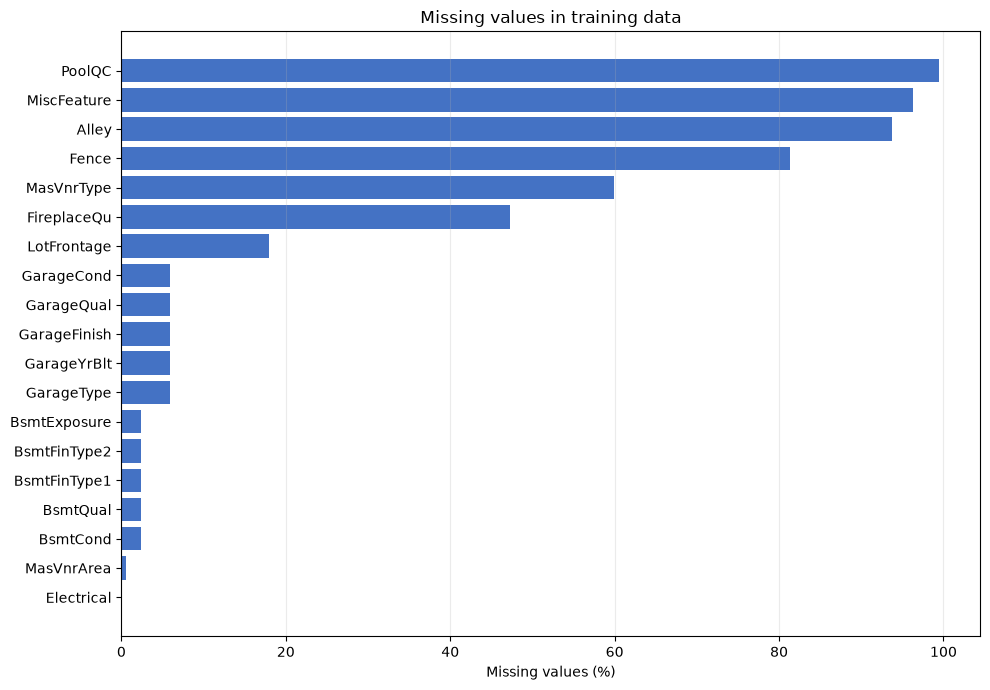

In [6]:
top_missing = missing_summary.head(20).sort_values("train_missing_pct")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_missing.index, top_missing["train_missing_pct"], color="#4472C4")
ax.set_title("Missing values in training data")
ax.set_xlabel("Missing values (%)")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "missing_values_train.png", dpi=160, bbox_inches="tight")
plt.show()

In [7]:
absence_means_none = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature",
]

numeric_absence_as_zero = ["MasVnrArea"]
numeric_missing_needs_imputation = ["LotFrontage", "GarageYrBlt"]
categorical_missing_needs_imputation = ["Electrical"]

missing_strategy = pd.DataFrame(
    {
        "group": [
            "Structural absence → 'None'",
            "Structural absence → 0",
            "Numeric unknown → median + optional missing indicator",
            "Categorical unknown → most frequent",
        ],
        "features": [
            ", ".join(absence_means_none),
            ", ".join(numeric_absence_as_zero),
            ", ".join(numeric_missing_needs_imputation),
            ", ".join(categorical_missing_needs_imputation),
        ],
    }
)
display(missing_strategy)

,group,features
0,Structural absence → 'None',"Alley, MasVnrType, BsmtQual, BsmtCond, BsmtExp..."
1,Structural absence → 0,MasVnrArea
2,Numeric unknown → median + optional missing in...,"LotFrontage, GarageYrBlt"
3,Categorical unknown → most frequent,Electrical


Recommended handling:

- fill structural-absence categories with an explicit value such as `"None"`;
- use `0` for `MasVnrArea` when `MasVnrType` indicates no veneer;
- impute genuinely unknown numeric values inside the pipeline, preferably with the training median and a missing indicator;
- impute `Electrical` with the most frequent training category;
- do not delete test rows, and avoid deleting training rows unless a later experiment provides a documented reason;
- fit every imputer and encoder only on training data or within each cross-validation fold.

### 1.5 Target distribution

House prices are positive and right-skewed. This matters because RMSE is sensitive to expensive outliers. The modeling team should report metrics in dollars on the original scale and may also compare a `log1p(SalePrice)` target transformation.

In [8]:
target_summary = train["SalePrice"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).to_frame("SalePrice")
target_skew = train["SalePrice"].skew()

display(target_summary)
print(f"SalePrice skewness: {target_skew:.3f}")

,SalePrice
count,"1,314.000"
mean,"181,045.475"
std,"79,863.286"
min,"34,900.000"
1%,"61,179.790"
25%,"130,000.000"
50%,"162,950.000"
75%,"214,000.000"
99%,"445,447.070"
max,"755,000.000"


SalePrice skewness: 1.876


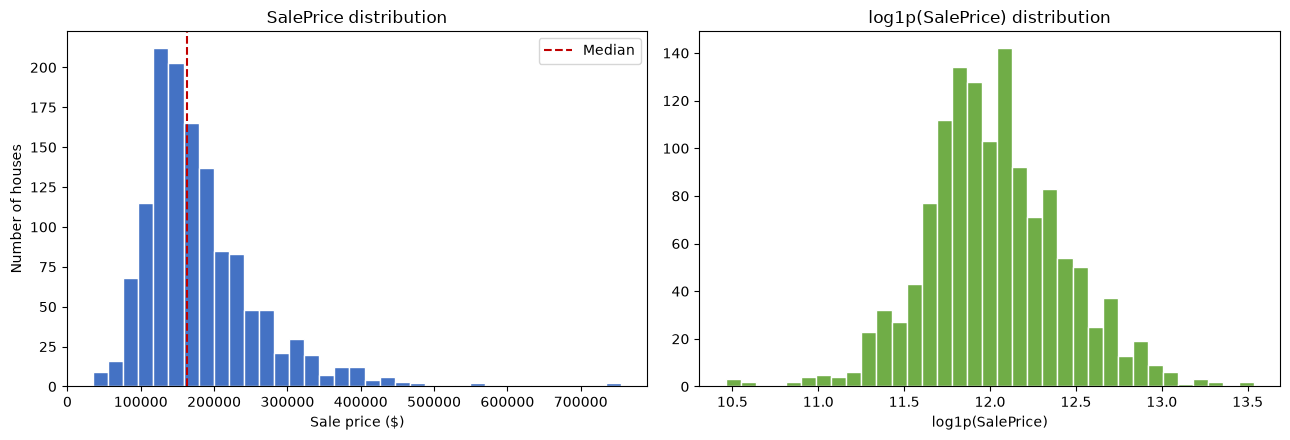

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(train["SalePrice"], bins=35, color="#4472C4", edgecolor="white")
axes[0].axvline(train["SalePrice"].median(), color="#C00000", linestyle="--", label="Median")
axes[0].set_title("SalePrice distribution")
axes[0].set_xlabel("Sale price ($)")
axes[0].set_ylabel("Number of houses")
axes[0].legend()

log_target = np.log1p(train["SalePrice"])
axes[1].hist(log_target, bins=35, color="#70AD47", edgecolor="white")
axes[1].set_title("log1p(SalePrice) distribution")
axes[1].set_xlabel("log1p(SalePrice)")

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "saleprice_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

### 1.6 Numerical relationships with price

Correlation is useful for finding associations, but it does not prove that a feature causes the price. Categorical features also need separate analysis because they do not appear in this numeric correlation table.

In [10]:
numeric_correlations = (
    train.select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .drop(labels=["SalePrice", "Id"])
    .sort_values(key=np.abs, ascending=False)
    .rename("correlation_with_SalePrice")
    .to_frame()
)

display(numeric_correlations.head(15))
numeric_correlations.to_csv(ARTIFACT_DIR / "numeric_target_correlations.csv")

,correlation_with_SalePrice
OverallQual,0.793
GrLivArea,0.697
GarageCars,0.642
GarageArea,0.633
TotalBsmtSF,0.614
1stFlrSF,0.605
FullBath,0.555
YearBuilt,0.530
TotRmsAbvGrd,0.529
YearRemodAdd,0.511


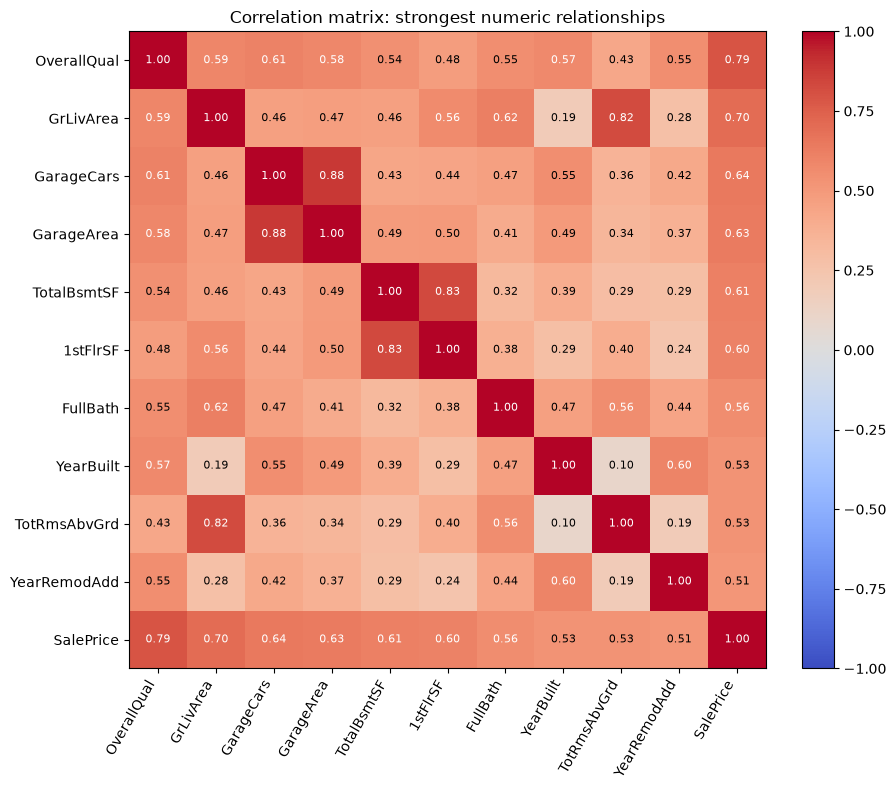

In [11]:
top_numeric = numeric_correlations.head(10).index.tolist()
heatmap_columns = top_numeric + ["SalePrice"]
corr_matrix = train[heatmap_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_columns)), heatmap_columns, rotation=60, ha="right")
ax.set_yticks(range(len(heatmap_columns)), heatmap_columns)

for row in range(len(heatmap_columns)):
    for column in range(len(heatmap_columns)):
        value = corr_matrix.iloc[row, column]
        text_color = "white" if abs(value) > 0.55 else "black"
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

ax.set_title("Correlation matrix: strongest numeric relationships")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "numeric_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

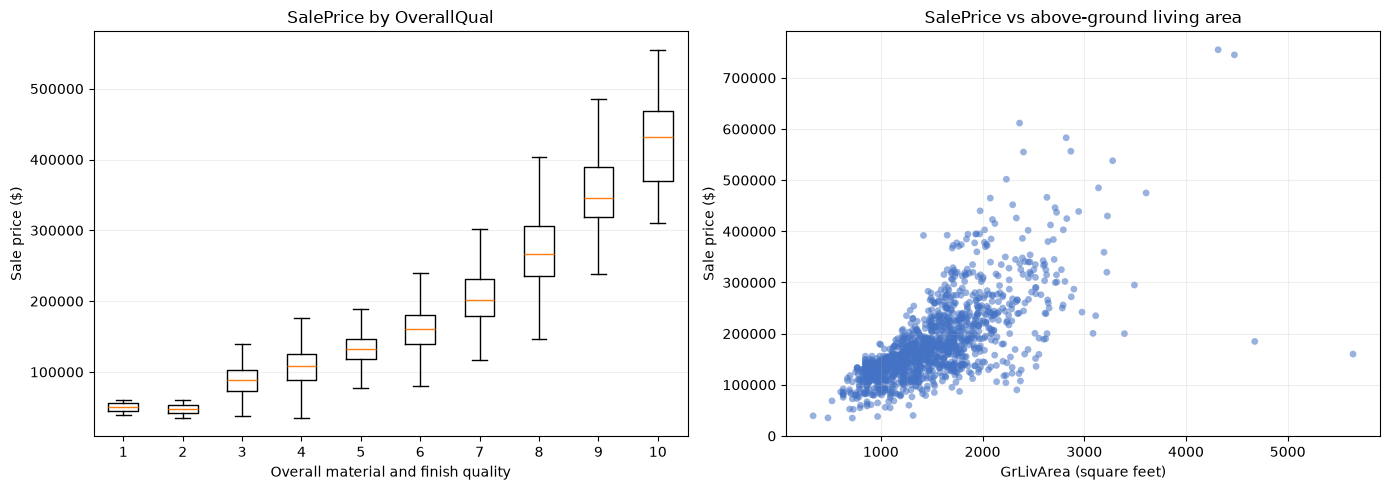

In [12]:
quality_levels = sorted(train["OverallQual"].unique())
price_by_quality = [
    train.loc[train["OverallQual"] == quality, "SalePrice"] for quality in quality_levels
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(price_by_quality, tick_labels=quality_levels, showfliers=False)
axes[0].set_title("SalePrice by OverallQual")
axes[0].set_xlabel("Overall material and finish quality")
axes[0].set_ylabel("Sale price ($)")
axes[0].grid(axis="y", alpha=0.2)

axes[1].scatter(
    train["GrLivArea"],
    train["SalePrice"],
    alpha=0.55,
    s=24,
    color="#4472C4",
    edgecolors="none",
)
axes[1].set_title("SalePrice vs above-ground living area")
axes[1].set_xlabel("GrLivArea (square feet)")
axes[1].set_ylabel("Sale price ($)")
axes[1].grid(alpha=0.2)

fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "key_price_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

### 1.7 Neighborhood effect

Neighborhood has many categories and a visible relationship with price. It should be retained and one-hot encoded rather than replaced with arbitrary integer codes. The plot uses medians because they are less sensitive to a few very expensive houses.

,median_price,mean_price,house_count
Neighborhood,,,
NridgHt,"317,000.000","319,981.887",71
NoRidge,"302,000.000","333,488.121",33
StoneBr,"282,000.000","318,570.727",22
Timber,"228,000.000","241,752.171",35
Somerst,"226,850.000","228,259.789",76
Veenker,"218,000.000","238,772.727",11
Crawfor,"200,624.000","207,361.356",45
CollgCr,"200,070.500","199,930.471",140
ClearCr,"196,000.000","208,858.923",26


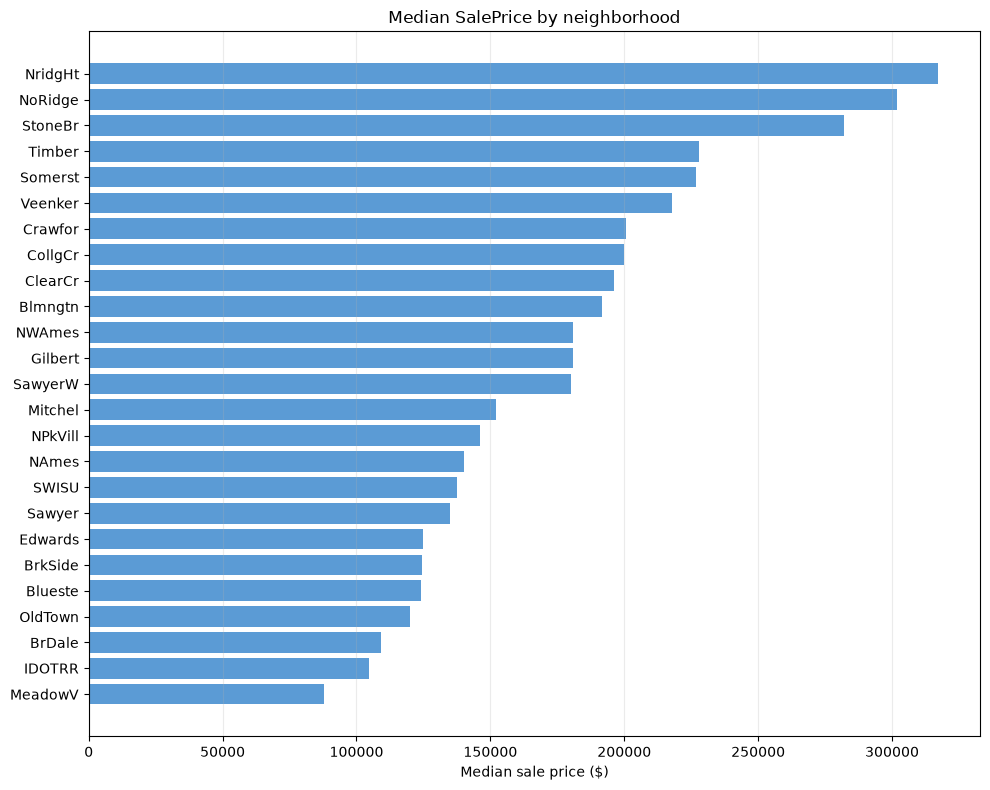

In [13]:
neighborhood_summary = (
    train.groupby("Neighborhood")["SalePrice"]
    .agg(median_price="median", mean_price="mean", house_count="size")
    .sort_values("median_price")
)
display(neighborhood_summary.sort_values("median_price", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(neighborhood_summary.index, neighborhood_summary["median_price"], color="#5B9BD5")
ax.set_title("Median SalePrice by neighborhood")
ax.set_xlabel("Median sale price ($)")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "neighborhood_median_prices.png", dpi=160, bbox_inches="tight")
plt.show()

neighborhood_summary.to_csv(ARTIFACT_DIR / "neighborhood_price_summary.csv")

### 1.8 Handoff to the preprocessing and modeling team

Verified findings:

- the training set has 1,314 rows and the final test set has 146 rows;
- both datasets have 81 columns, including `Id` and `SalePrice`;
- there are no duplicate rows, duplicate IDs, or overlapping IDs between the splits;
- after removing `Id` and `SalePrice`, there are 79 candidate predictors;
- the training target median is $162,950 and the mean is approximately $181,045;
- `SalePrice` is strongly right-skewed (skewness about 1.88);
- the strongest linear numeric associations include `OverallQual`, `GrLivArea`, garage capacity/area, basement area, and first-floor area;
- many missing categorical values describe structural absence, not corrupted data.

Preprocessing contract for the next teammate:

1. Preserve every test row and preserve `Id` separately for traceability.
2. Remove `Id` and `SalePrice` from `X`; quarantine test `SalePrice` until final evaluation.
3. Cast `MSSubClass` to categorical.
4. Fill structural-absence categorical fields with `"None"`.
5. Handle genuine numeric/categorical unknowns using imputers fitted inside the pipeline.
6. One-hot encode nominal categories with unknown-category handling enabled.
7. Compare models using the same validation folds and report at least MAE, RMSE, and R².
8. Consider a log-transformed target, but convert predictions back to dollars before reporting final MAE/RMSE.

No model has been selected in this section. That decision belongs to the validation results, not to EDA.

In [14]:
assert len(test) == original_test_row_count, "Test rows were accidentally removed."
print(f"Integrity check passed: all {original_test_row_count} test rows are still present.")
print(f"EDA artifacts saved to: {ARTIFACT_DIR.resolve()}")

Integrity check passed: all 146 test rows are still present.
EDA artifacts saved to: /home/shindenis/programming-projects/aitu/ml/midterm/eda_artifacts


## 2. Data preprocessing and model training

_Reserved for the second team member._

## 3. Model validation, comparison, and final test evaluation

_Reserved for the third team member. Do not use `test.csv` results to choose or tune a model._